In [27]:
from dopplerguesser.predict.fetch_tles import fetch_tles
from dopplerguesser.predict.filters import filter_visibility, filter_heo, filter_geostationary, filter_by_doppler, filter_constellations
from dopplerguesser.predict.matcher import score_candidates
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
from dopplerguesser.predict.propagator import propagate_earth_rotation, propagate_fg_elliptic
from dopplerguesser.misc.curve_generator import generate_doppler_curve
from matplotlib import pyplot as plt

In [28]:
from time import perf_counter
from datetime import datetime
from datetime import timezone

In [29]:
observer = Observer(lat=55.7558, lon=37.6176, alt=200)  # Moscow

In [30]:
now = datetime.now(tz=timezone.utc)
print(now)
ts = now.timestamp()
print(ts)

2026-01-30 20:48:06.864110+00:00
1769806086.86411


In [31]:
fetched_tles = fetch_tles(ts)
print(f"Fetched {len(fetched_tles)} TLEs")

Fetched 14294 TLEs


In [32]:
with open('activesatellites.txt', 'w') as f:
    for sat in fetched_tles:
        f.write(f"{sat.satellite.name}\n")

In [33]:
# Filtering
print('Initial length:', len(fetched_tles))

t1 = perf_counter()
satellites = filter_constellations(fetched_tles, constellations_to_remove=['starlink', 'oneweb'])
t2 = perf_counter()
print('After constellation filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_geostationary(satellites)
t2 = perf_counter()
print('After geostationary filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_heo(satellites)
t2 = perf_counter()
print('After HEO filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_visibility(satellites, observer, ts, min_elevation=0.0)
t2 = perf_counter()
print('After visibility filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

Initial length: 14294
After constellation filter: 4103
Took 0.009 seconds

After geostationary filter: 3301
Took 0.001 seconds

After HEO filter: 3299
Took: 0.001 seconds

After visibility filter: 219
Took: 0.239 seconds



In [34]:
# Earth rotation Propagation
t1 = perf_counter()
observer.compute_track(ts)
t2 = perf_counter()
print('Earth rotation propagation took {:.3f} seconds\n'.format(t2 - t1))

Earth rotation propagation took 0.010 seconds



In [35]:
# Satellite propagation
t1 = perf_counter()
for sat in satellites:
    sat.compute_initial_state(ts)
t2 = perf_counter()
print('Satellite propagation took {:.3f} seconds\n'.format(t2 - t1))

Satellite propagation took 0.055 seconds



OPS 5712 (P/L 153)
[(np.int64(0), np.float64(2199962203.931759)), (np.int64(1), np.float64(2199962047.9381814)), (np.int64(2), np.float64(2199962060.8466487)), (np.int64(3), np.float64(2199961910.3695674)), (np.int64(4), np.float64(2199962061.6142497)), (np.int64(5), np.float64(2199961963.958049)), (np.int64(6), np.float64(2199961906.688917)), (np.int64(7), np.float64(2199961874.8689694)), (np.int64(8), np.float64(2199961912.9905047)), (np.int64(9), np.float64(2199961867.16724)), (np.int64(10), np.float64(2199961821.388914)), (np.int64(11), np.float64(2199961810.1659074)), (np.int64(12), np.float64(2199961650.653434)), (np.int64(13), np.float64(2199961700.2267194)), (np.int64(14), np.float64(2199961537.907431)), (np.int64(15), np.float64(2199961505.780145)), (np.int64(16), np.float64(2199961474.8057284)), (np.int64(17), np.float64(2199961568.042278)), (np.int64(18), np.float64(2199961450.972437)), (np.int64(19), np.float64(2199961399.6322885)), (np.int64(20), np.float64(2199961483.4269

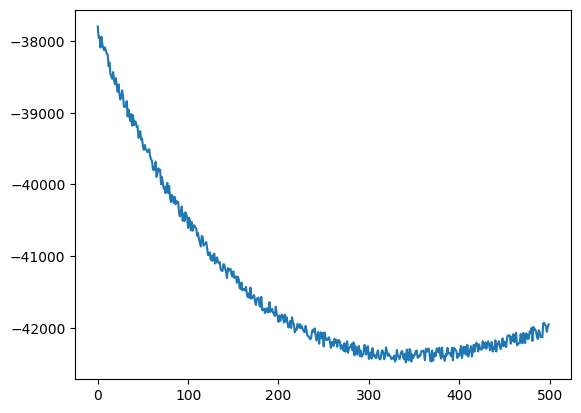

In [36]:
# Mock doppler curve generation
unknownsatellite = satellites[0]
freq = 2.2e9
print(unknownsatellite.satellite.name)
curve = generate_doppler_curve(unknownsatellite, observer, freq, ts)
print(curve)

curveclean = [(x, y - freq) for x, y in curve]

plt.plot(*zip(*curveclean))
plt.show()

In [37]:
# Apply Doppler filter
t1 = perf_counter()
satellites = filter_by_doppler(satellites, observer, ts, freq, curve[0][1])
t2 = perf_counter()
print('After Doppler filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))
print('Remaining candidates:')
for sat in satellites:
    print(sat.satellite.name)

After Doppler filter: 9
Took: 0.003 seconds

Remaining candidates:
OPS 5712 (P/L 153)
CENTISPACE-1 S9
BALKAN-1
TRANSPORTER-12CN
QIANFAN-59
KUIPER-00050
PELICAN-5
TRANSPORTER-15CD
NUSAT-47


In [38]:
# Propagate candidates using FG elliptic model
t1 = perf_counter()
for sat in satellites:
    sat.compute_track(ts)
t2 = perf_counter()
print('FG elliptic propagation took {:.3f} seconds\n'.format(t2 - t1))

FG elliptic propagation took 0.239 seconds



In [39]:
# Score candidates
t1 = perf_counter()
scored_candidates = score_candidates(satellites, curve, freq, observer)
t2 = perf_counter()
print('\nScoring took {:.3f} seconds\n'.format(t2 - t1))
for sat, rmse in scored_candidates:
    print(f'{sat.satellite.name}: {rmse:.6f}')


Scoring took 0.099 seconds

OPS 5712 (P/L 153): 58.698648
QIANFAN-59: 416.649810
CENTISPACE-1 S9: 2608.944877
NUSAT-47: 3391.555921
TRANSPORTER-15CD: 3709.061830
PELICAN-5: 3712.250639
BALKAN-1: 5259.415478
KUIPER-00050: 5415.125086
TRANSPORTER-12CN: 7745.833841
